# Sensitivity of `ConDrift` and `CatDrift`

This notebook measures two distinct properties of the **tinyshift** detectors:

1. **False-positive rate (type I error):** frequency of alerts when the reference and current samples come from the same distribution. With `alpha=0.05`, we expect approximately 5%.
2. **Power:** frequency of alerts when drift of a known intensity is introduced. The curve shows the magnitude at which drift is detected consistently.

We use NannyML's public **Synthetic Car Loan** dataset, which provides reference/monitoring partitions and both continuous and categorical columns. Its repository describes it as a dataset for monitoring tests and demos. We then apply controlled interventions to the empirical reference distribution to obtain known ground truth—something that a real-world split alone cannot provide.

Sources: [NannyML dataset](https://github.com/NannyML/nannyml-datasets) · [dataset documentation](https://nannyml.readthedocs.io/en/v0.10.4/datasets/binary_car_loan.html) · [TableShift, a tabular distribution-shift benchmark](https://arxiv.org/abs/2312.07577)

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Supports execution from either the repository root or tinyshift/examples.
for candidate in (Path.cwd(), Path.cwd().parent, Path.cwd().parents[1]):
    if (candidate / "tinyshift" / "drift").exists():
        sys.path.insert(0, str(candidate))
        break

from tinyshift.drift import CatDrift, ConDrift

SEED = 20260922
ALPHA = 0.05
N_RESAMPLES = 199       # minimum p-value resolution: 1/200 = 0.005
N_TRIALS = 60           # increase to 200+ for narrower intervals
SAMPLE_SIZE = 500
rng = np.random.default_rng(SEED)

## 1. Data

Each period contains 50,000 rows. The cell first checks `/tmp` (useful when the files have already been downloaded locally) and otherwise reads them directly from GitHub. No additional benchmark package is required.

In [2]:
URLS = {
    "reference": "https://raw.githubusercontent.com/NannyML/nannyml/main/nannyml/datasets/data/synthetic_car_loan_reference.csv",
    "monitoring": "https://raw.githubusercontent.com/NannyML/nannyml/main/nannyml/datasets/data/synthetic_car_loan_analysis.csv",
}
LOCAL = {"reference": Path("/tmp/car_ref.csv"), "monitoring": Path("/tmp/car_analysis.csv")}

def load_csv(period):
    source = LOCAL[period] if LOCAL[period].exists() else URLS[period]
    return pd.read_csv(source)

reference_df = load_csv("reference")
monitoring_df = load_csv("monitoring")
print("reference:", reference_df.shape, "monitoring:", monitoring_df.shape)
reference_df.head(3)

reference: (50000, 12) monitoring: (50000, 11)


,id,car_value,salary_range,debt_to_income_ratio,loan_length,repaid_loan_on_prev_car,size_of_downpayment,driver_tenure,repaid,timestamp,y_pred_proba,y_pred
0,0,39811.0,40K - 60K €,0.632950,19.0,False,40%,0.212653,1.0,2018-01-01 00:00:00.000,0.99,1
1,1,12679.0,40K - 60K €,0.718627,7.0,True,10%,4.927549,0.0,2018-01-01 00:08:43.152,0.07,0
2,2,19847.0,40K - 60K €,0.721724,17.0,False,0%,0.520817,1.0,2018-01-01 00:17:26.304,1.00,1


We use `debt_to_income_ratio` for `ConDrift` and `salary_range` for `CatDrift`. Neither contains missing values, and together they represent the two data types accepted by the detectors. The analysis is univariate, consistent with the current API.

In [3]:
CONTINUOUS = "debt_to_income_ratio"
CATEGORICAL = "salary_range"

for column in (CONTINUOUS, CATEGORICAL):
    print(f"{column}: missing in reference={reference_df[column].isna().sum()}, monitoring={monitoring_df[column].isna().sum()}")
print("\nCategories and proportions in the reference data:")
display(reference_df[CATEGORICAL].value_counts(normalize=True).rename("proporção").to_frame())

debt_to_income_ratio: missing in reference=0, monitoring=0
salary_range: missing in reference=0, monitoring=0

Categories and proportions in the reference data:


,proporção
salary_range,
0 - 20K €,0.39836
20K - 40K €,0.30094
40K - 60K €,0.19954
60K+ €,0.10116


## 2. Real-world comparison: reference vs. monitoring

This result indicates whether there is evidence of change in the published dataset, but it does **not** determine by itself whether a detector is overly sensitive: the population ground truth for these two periods is unknown, and with 50,000 observations even small changes may be statistically detectable.

In [4]:
real_results = {
    "ConDrift": ConDrift(alpha=ALPHA, n_resamples=499, random_state=SEED)
        .fit(reference_df[CONTINUOUS]).predict(monitoring_df[CONTINUOUS]),
    "CatDrift": CatDrift(alpha=ALPHA, n_resamples=499, random_state=SEED)
        .fit(reference_df[CATEGORICAL]).predict(monitoring_df[CATEGORICAL]),
}
pd.DataFrame({name: vars(result) for name, result in real_results.items()}).T

,score,threshold,p_value,drift,reference_size,current_size
ConDrift,0.005201,0.012164,0.556,False,50000,50000
CatDrift,0.075278,0.007892,0.002,True,50000,50000


## 3. Sensitivity benchmark design

In each repetition, while keeping the reference sample fixed, we draw:

- **null:** a current sample from the same empirical distribution;
- **continuous:** a location shift of `delta × standard deviation` applied to the entire current sample;
- **categorical:** a `contamination` fraction of the sample replaced with an unseen category (`NEW_CATEGORY`).

The detection rate at zero intensity estimates the false-positive rate. At nonzero intensities, it estimates power. Each call receives a different seed to avoid repeating the same Monte Carlo permutations.

In [5]:
continuous_pool = reference_df[CONTINUOUS].dropna().to_numpy(float)
categorical_pool = reference_df[CATEGORICAL].dropna().astype(object).to_numpy()

# The reference remains fixed as it would in production; current samples vary by trial.
ref_cont = rng.choice(continuous_pool, SAMPLE_SIZE, replace=False)
ref_cat = rng.choice(categorical_pool, SAMPLE_SIZE, replace=False)
cont_sd = float(np.std(ref_cont))

continuous_levels = np.array([0.0, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00])
categorical_levels = np.array([0.0, 0.02, 0.05, 0.10, 0.20, 0.30])

records = []
for detector_name, levels in (("ConDrift", continuous_levels), ("CatDrift", categorical_levels)):
    for level in levels:
        for trial in range(N_TRIALS):
            seed = SEED + trial + int(level * 10_000) + (0 if detector_name == "ConDrift" else 1_000_000)
            trial_rng = np.random.default_rng(seed)
            if detector_name == "ConDrift":
                current = trial_rng.choice(continuous_pool, SAMPLE_SIZE, replace=True) + level * cont_sd
                result = ConDrift(ALPHA, N_RESAMPLES, seed).fit(ref_cont).predict(current)
            else:
                current = trial_rng.choice(categorical_pool, SAMPLE_SIZE, replace=True).astype(object)
                replace = trial_rng.random(SAMPLE_SIZE) < level
                current[replace] = "NEW_CATEGORY"
                result = CatDrift(ALPHA, N_RESAMPLES, seed).fit(ref_cat).predict(current)
            records.append({
                "detector": detector_name,
                "intensity": float(level),
                "trial": trial,
                "drift": bool(result.drift),
                "p_value": result.p_value,
                "score": result.score,
            })

trials = pd.DataFrame(records)
summary = (trials.groupby(["detector", "intensity"], as_index=False)
           .agg(detection_rate=("drift", "mean"), mean_score=("score", "mean")))
summary

,detector,intensity,detection_rate,mean_score
0,CatDrift,0.00,0.050000,0.040182
1,CatDrift,0.02,0.950000,0.108349
2,CatDrift,0.05,1.000000,0.165566
3,CatDrift,0.10,1.000000,0.230945
4,CatDrift,0.20,1.000000,0.333032
5,CatDrift,0.30,1.000000,0.413066
6,ConDrift,0.00,0.000000,0.055888
7,ConDrift,0.10,0.383333,0.119705
8,ConDrift,0.20,1.000000,0.205760
9,ConDrift,0.30,1.000000,0.302342


## 4. Uncertainty and power curves

The error bars are 95% Wilson intervals for the detection proportion. With 60 repetitions, a 5% estimate still has considerable uncertainty; for a formal audit, increase `N_TRIALS` to 500 or more.

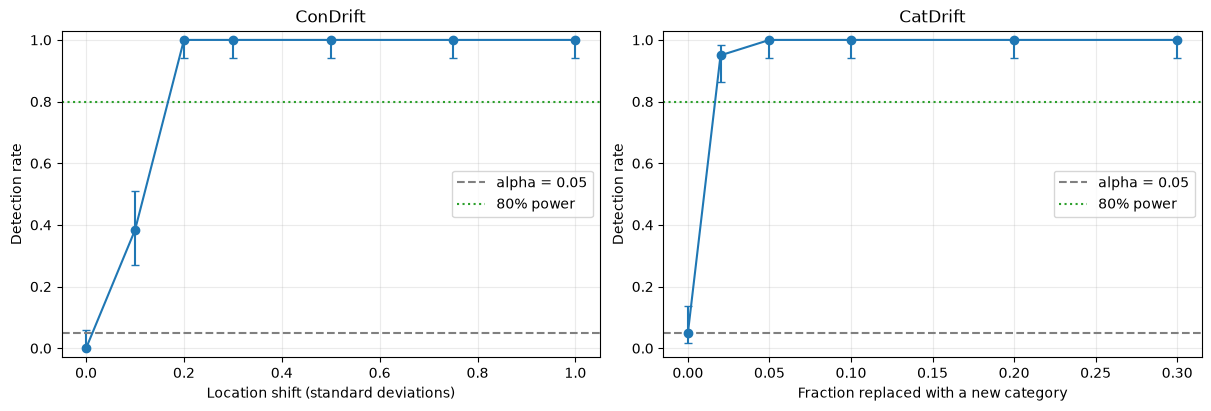

,detector,intensity,detection_rate,ci_low,ci_high
0,CatDrift,0.00,0.050000,0.017150,0.137005
1,CatDrift,0.02,0.950000,0.862995,0.982850
2,CatDrift,0.05,1.000000,0.939828,1.000000
3,CatDrift,0.10,1.000000,0.939828,1.000000
4,CatDrift,0.20,1.000000,0.939828,1.000000
5,CatDrift,0.30,1.000000,0.939828,1.000000
6,ConDrift,0.00,0.000000,0.000000,0.060172
7,ConDrift,0.10,0.383333,0.270883,0.509824
8,ConDrift,0.20,1.000000,0.939828,1.000000
9,ConDrift,0.30,1.000000,0.939828,1.000000


In [6]:
from scipy.stats import norm

def wilson_interval(successes, total, confidence=0.95):
    z = norm.ppf(1 - (1 - confidence) / 2)
    p = successes / total
    denom = 1 + z**2 / total
    center = (p + z**2 / (2 * total)) / denom
    half = z * np.sqrt(p * (1 - p) / total + z**2 / (4 * total**2)) / denom
    return center - half, center + half

rows = []
for (detector, intensity), group in trials.groupby(["detector", "intensity"]):
    low, high = wilson_interval(int(group["drift"].sum()), len(group))
    rows.append({"detector": detector, "intensity": intensity,
                 "detection_rate": group["drift"].mean(), "ci_low": low, "ci_high": high})
power = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, detector, xlabel in zip(
    axes, ["ConDrift", "CatDrift"],
    ["Location shift (standard deviations)", "Fraction replaced with a new category"],
):
    part = power[power.detector == detector]
    yerr = np.maximum(
        np.vstack([part.detection_rate - part.ci_low, part.ci_high - part.detection_rate]),
        0.0,
    )
    ax.errorbar(part.intensity, part.detection_rate, yerr=yerr, marker="o", capsize=3)
    ax.axhline(ALPHA, color="gray", ls="--", label=f"alpha = {ALPHA}")
    ax.axhline(0.8, color="tab:green", ls=":", label="80% power")
    ax.set(title=detector, xlabel=xlabel, ylabel="Detection rate", ylim=(-0.03, 1.03))
    ax.grid(alpha=0.25)
    ax.legend()
plt.show()
power

## 5. Automated assessment

In [7]:
def first_level_at(detector, target=0.80):
    part = power[(power.detector == detector) & (power.intensity > 0)]
    reached = part[part.detection_rate >= target]
    return None if reached.empty else float(reached.iloc[0].intensity)

null_rates = power[power.intensity == 0].set_index("detector")
for detector in ("ConDrift", "CatDrift"):
    row = null_rates.loc[detector]
    print(f"{detector}: false-positive rate={row.detection_rate:.1%} "
          f"(95% CI {row.ci_low:.1%}–{row.ci_high:.1%}); "
          f"first level with >=80% power={first_level_at(detector)}")

print("\nPractical interpretation:")
print("- there is no evidence of oversensitivity if 5% falls within the false-positive CI;")
print("- high power for small shifts is desirable as long as the false-positive rate remains calibrated;")
print("- when testing many columns/windows, apply a multiple-testing correction or expect more aggregate alerts.")

ConDrift: false-positive rate=0.0% (95% CI 0.0%–6.0%); first level with >=80% power=0.2
CatDrift: false-positive rate=5.0% (95% CI 1.7%–13.7%); first level with >=80% power=0.02

Practical interpretation:
- there is no evidence of oversensitivity if 5% falls within the false-positive CI;
- high power for small shifts is desirable as long as the false-positive rate remains calibrated;
- when testing many columns/windows, apply a multiple-testing correction or expect more aggregate alerts.


## Conclusion and limitations

A single `drift=True` result is not enough to conclude that a detector is overly sensitive. The primary diagnostic is the false-positive rate at zero intensity compared with `alpha`. The power curve quantifies the smallest shift detected consistently **at this sample size**.

Limitations: observations are treated as exchangeable; temporal dependence violates this assumption. The benchmark is univariate, like the detectors. An unseen category is a deliberately interpretable scenario and does not represent every type of categorical drift. When monitoring many features or windows, the family-wise false-positive risk increases; consider Benjamini–Hochberg, Bonferroni, or an aggregate alerting rule.